# Fair comparison: transformer vs. GARCH vs. baselines - same test period

Every model scored so far, evaluated on the exact same window: **2023-04-12 to 2026-08-05** - GARCH's actual backtest test period (notebook 07).

**One honesty caveat**: part of this period (2023-04-12 to 2024-02-14) was part of the transformer's own *validation* set, used to pick its best checkpoint during training. That's not full training exposure, but it's not perfectly blind either - worth keeping in mind rather than treating this as a 100% clean test. The linear baselines and naive prediction remain honestly out-of-sample throughout, since they were only fit on data before 2021-08-25.

In [1]:
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

WINDOW_SIZE = 30
GARCH_TEST_START = "2023-04-12"
GARCH_TEST_END = "2026-08-05"

gold = pd.read_csv("../data/gold_futures.csv", skiprows=[1, 2], index_col=0, parse_dates=True)
returns = gold["Close"].pct_change().dropna() * 100


def create_windows(returns, window_size):
    values = returns.values
    X, y, dates = [], [], []
    for start in range(len(values) - window_size):
        end = start + window_size
        X.append(values[start:end])
        y.append(abs(values[end]))
        dates.append(returns.index[end])
    return np.array(X, dtype=np.float64), np.array(y, dtype=np.float64), pd.DatetimeIndex(dates)


X, y, dates = create_windows(returns, WINDOW_SIZE)

n = len(X)
train_end = int(n * 0.70)  # same split boundary used to train the transformer and fit the linear models
X_train, y_train = X[:train_end], y[:train_end]

# Filter to GARCH's exact test period
mask = (dates >= GARCH_TEST_START) & (dates <= GARCH_TEST_END)
X_test, y_test, dates_test = X[mask], y[mask], dates[mask]

print(f"Test examples in GARCH's test period: {len(X_test)}")
print(f"Date range: {dates_test[0].date()} to {dates_test[-1].date()}")

Test examples in GARCH's test period: 834
Date range: 2023-04-12 to 2026-08-05


## Transformer predictions on this period

In [2]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[: x.size(1)]


class VolatilityTransformer(nn.Module):
    def __init__(self, d_model=32, num_heads=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.input_projection = nn.Linear(1, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads, dim_feedforward=64, dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_head = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_projection(x)
        x = self.pos_encoding(x)
        x = self.encoder(x)
        last_day = x[:, -1, :]
        out = self.output_head(last_day)
        return nn.functional.softplus(out).squeeze(-1)


checkpoint = torch.load("../models/gold_transformer.pt", weights_only=False)
train_mean = checkpoint["train_mean"]
train_std = checkpoint["train_std"]

transformer = VolatilityTransformer()
transformer.load_state_dict(checkpoint["state_dict"])
transformer.eval()

X_test_norm = (X_test - train_mean) / train_std
X_test_tensor = torch.tensor(X_test_norm, dtype=torch.float32).unsqueeze(-1)

with torch.no_grad():
    predictions_transformer = transformer(X_test_tensor).numpy()

rmse_transformer = np.sqrt(np.mean((predictions_transformer - y_test) ** 2))
print(f"Transformer RMSE: {rmse_transformer:.4f}")

Transformer RMSE: 0.8893


## Linear baselines and naive, on the same period

In [3]:
# Naive
naive_prediction = np.full_like(y_test, y_train.mean())
rmse_naive = np.sqrt(np.mean((naive_prediction - y_test) ** 2))

# Linear regression, 30 raw values
X_train_design = np.hstack([np.ones((len(X_train), 1)), X_train])
X_test_design = np.hstack([np.ones((len(X_test), 1)), X_test])
coeffs_full, *_ = np.linalg.lstsq(X_train_design, y_train, rcond=None)
predictions_full = X_test_design @ coeffs_full
rmse_full = np.sqrt(np.mean((predictions_full - y_test) ** 2))

# Linear regression, 1 feature (recent realized vol)
recent_vol_train = np.abs(X_train).mean(axis=1)
recent_vol_test = np.abs(X_test).mean(axis=1)
X_train_simple = np.column_stack([np.ones(len(X_train)), recent_vol_train])
X_test_simple = np.column_stack([np.ones(len(X_test)), recent_vol_test])
coeffs_simple, *_ = np.linalg.lstsq(X_train_simple, y_train, rcond=None)
predictions_simple = X_test_simple @ coeffs_simple
rmse_simple = np.sqrt(np.mean((predictions_simple - y_test) ** 2))

print(f"Naive RMSE:                     {rmse_naive:.4f}")
print(f"Linear (30 raw values) RMSE:    {rmse_full:.4f}")
print(f"Linear (1 feature) RMSE:        {rmse_simple:.4f}")

Naive RMSE:                     0.9364
Linear (30 raw values) RMSE:    0.9398
Linear (1 feature) RMSE:        0.8788


## The honest, final scoreboard - all models, same test period

In [4]:
GARCH_RMSE = 0.9032  # from notebook 07, same test period

results = pd.DataFrame({
    "Model": ["Naive (train mean)", "Linear (30 raw values)", "Linear (1 feature: recent vol)", "Transformer", "GARCH(1,1)"],
    "RMSE": [rmse_naive, rmse_full, rmse_simple, rmse_transformer, GARCH_RMSE],
})
results["Improvement over naive"] = (1 - results["RMSE"] / rmse_naive) * 100
results.sort_values("RMSE").reset_index(drop=True)

,Model,RMSE,Improvement over naive
0,Linear (1 feature: recent vol),0.878754,6.158435
1,Transformer,0.889339,5.027973
2,"GARCH(1,1)",0.903200,3.547816
3,Naive (train mean),0.936423,0.000000
4,Linear (30 raw values),0.939816,-0.362437


## Recompute GARCH's actual daily forecast

Notebook 07 only stored the final RMSE, not the day-by-day predictions - refitting here (same settings, same split) so GARCH's forecast line can go on the same chart as everything else.

In [5]:
from arch import arch_model

garch_split_idx = int(len(returns) * 0.8)
garch_split_date = returns.index[garch_split_idx]

garch_model = arch_model(returns, mean="Constant", vol="Garch", p=1, q=1, dist="normal")
garch_result = garch_model.fit(last_obs=garch_split_date, disp="off")

garch_forecasts = garch_result.forecast(start=garch_split_date, horizon=1, reindex=False)
garch_volatility = np.sqrt(garch_forecasts.variance["h.1"])

print(f"GARCH forecasts generated: {len(garch_volatility)}")

GARCH forecasts generated: 834


## Plot 1: RMSE bar chart - all 5 models, lower is better

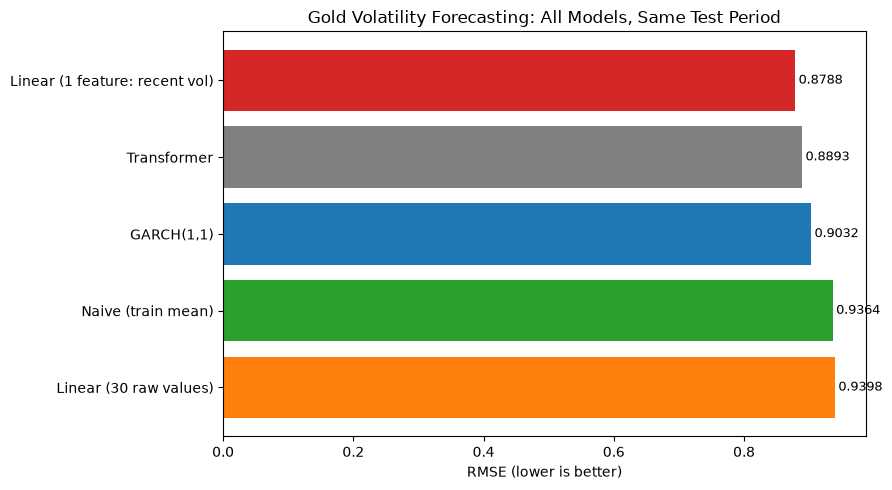

In [6]:
import matplotlib.pyplot as plt

results_sorted = results.sort_values("RMSE").reset_index(drop=True)
colors = ["tab:green", "tab:orange", "tab:red", "gray", "tab:blue"]
color_map = dict(zip(results["Model"], colors))
bar_colors = [color_map[m] for m in results_sorted["Model"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(results_sorted["Model"], results_sorted["RMSE"], color=bar_colors)
ax.set_xlabel("RMSE (lower is better)")
ax.set_title("Gold Volatility Forecasting: All Models, Same Test Period")
ax.invert_yaxis()

for bar, rmse in zip(bars, results_sorted["RMSE"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2, f"{rmse:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## Plot 2: every model's daily predictions vs. actual moves, over time

Note: GARCH's line is indexed by the day the forecast was *made* (one day before its target, same convention as notebook 07); all other series are indexed by the actual target date. This is a one-day offset, invisible at this timescale.

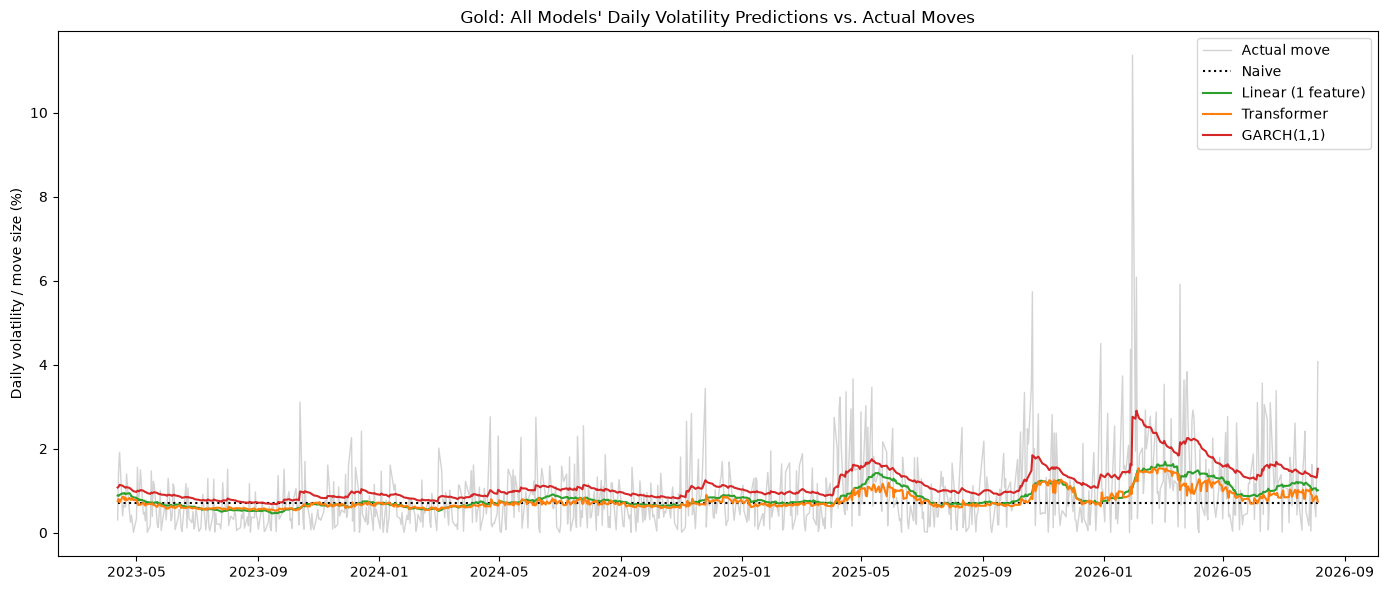

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(dates_test, y_test, color="lightgray", label="Actual move", linewidth=1)
ax.plot(dates_test, naive_prediction, color="black", linestyle=":", label="Naive", linewidth=1.5)
ax.plot(dates_test, predictions_simple, color="tab:green", label="Linear (1 feature)", linewidth=1.5)
ax.plot(dates_test, predictions_transformer, color="tab:orange", label="Transformer", linewidth=1.5)
ax.plot(garch_volatility.index, garch_volatility.values, color="tab:red", label="GARCH(1,1)", linewidth=1.5)

ax.set_title("Gold: All Models' Daily Volatility Predictions vs. Actual Moves")
ax.set_ylabel("Daily volatility / move size (%)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()